# DS201.3 Introduction to Data Science

## coursework : Classification of Online Game Players Engagement Level

### dataset:Online Gaming Behavior dataset

## 1.Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning Models and evaluation
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


## 2.Exploratory Data Analysis (EDA)

First 5 rows of the dataset:


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


Dataset shape (rows, columns):


(40034, 13)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(

...

Statistical Summary of Numerical Columns:


,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


Missing Values in Each Column:


PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64


Total missing values: 0


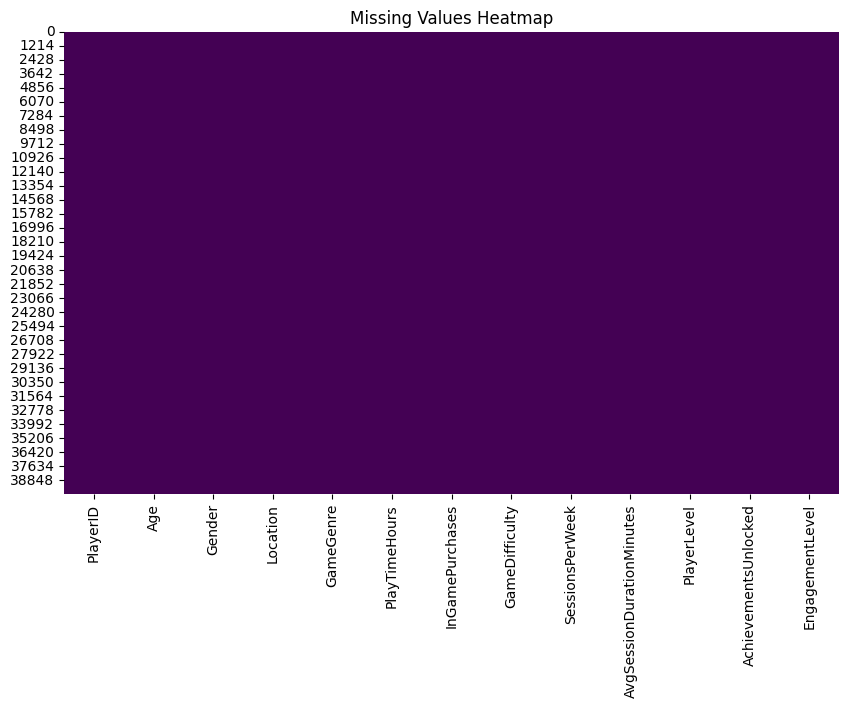

Number of duplicate rows:
0


In [2]:
#1.importing Data set
df = pd.read_csv(r"C:\Users\thuru\OneDrive\Desktop\38079 DS\online_gaming_behavior_dataset.csv")

#2. Data Exploration
print("First 5 rows of the dataset:")
display(df.head())

#3. Checking dataset size rows , columns
print("Dataset shape (rows, columns):")
display(df.shape)

#4. Checking data structure and missing values
print("Dataset Info:")
display(df.info())

#5. Statistical summary of numerical columns
print("Statistical Summary of Numerical Columns:")
display(df.describe())

#6. cheking for missing values
print("Missing Values in Each Column:")
display(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

#6.1 Visualize missing values using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

#7. Check and remove duplicate rows
print("Number of duplicate rows:")
print(df.duplicated().sum())

##7.1 Removing duplicate rows (no need there are no duplicate rows in the dataset)
#df = df.drop_duplicates()

## 3.Target Variable Distribution

EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64


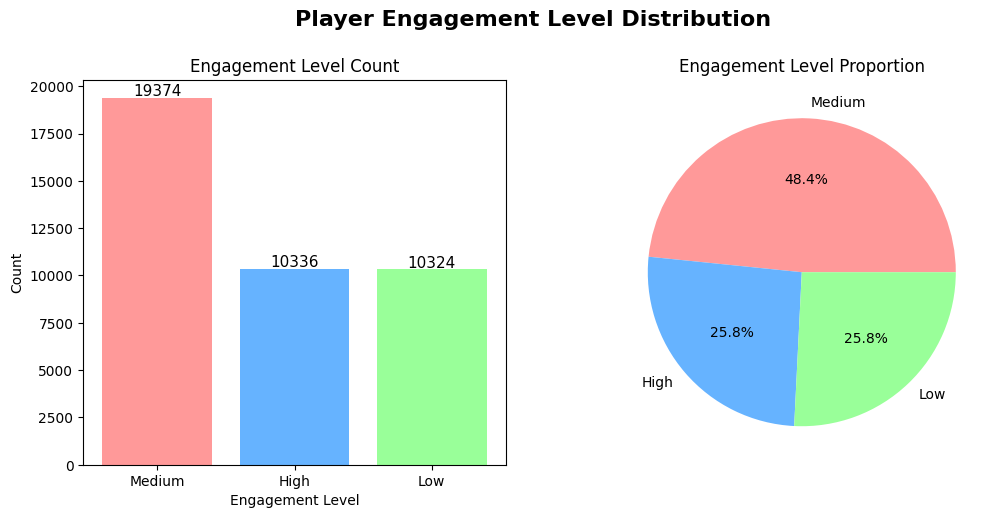

In [3]:
# Count players in each engagement level
counts = df['EngagementLevel'].value_counts()
print(counts)

# colors for the charts
my_colors = ['#ff9999', '#66b3ff', '#99ff99']

# Layout for side by side charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(counts.index, counts.values, color=my_colors)
axes[0].set_title('Engagement Level Count')
axes[0].set_xlabel('Engagement Level')
axes[0].set_ylabel('Count')
 
# Add player count on top of each bar
for i, count in enumerate(counts.values):
    axes[0].text(i, count + 100, str(count), ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=my_colors)
axes[1].set_title('Engagement Level Proportion')

plt.suptitle('Player Engagement Level Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.show()

## 4.Numerical Feature Distributions

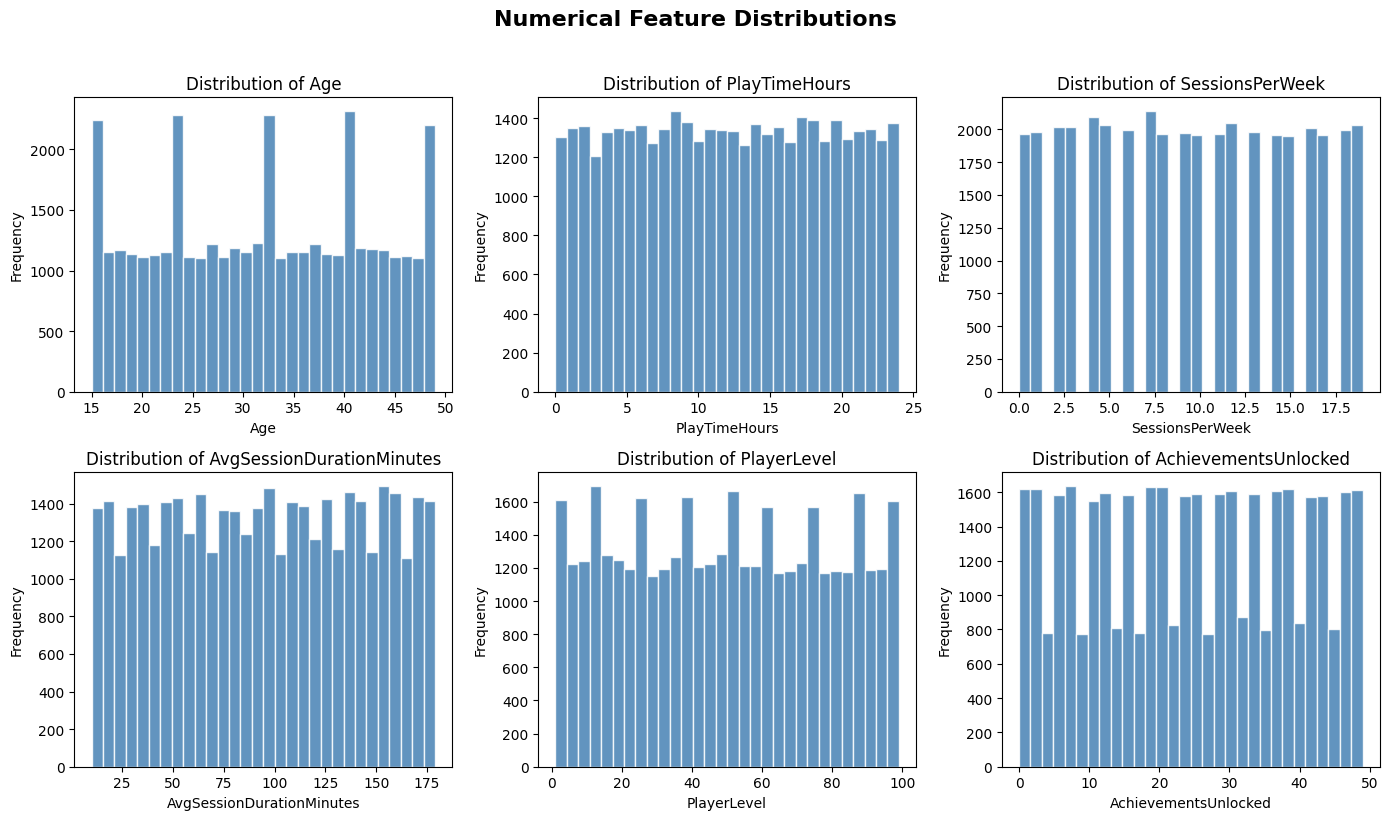

In [4]:
# numerical columns
num_cols = ['Age', 'PlayTimeHours', 'SessionsPerWeek', 
            'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']

# Creating histograms (row & column and widht & height)
fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 

# Flatten axes 
axes = axes.flatten()

# Plot each histogram
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5.Categorical feature Analysis

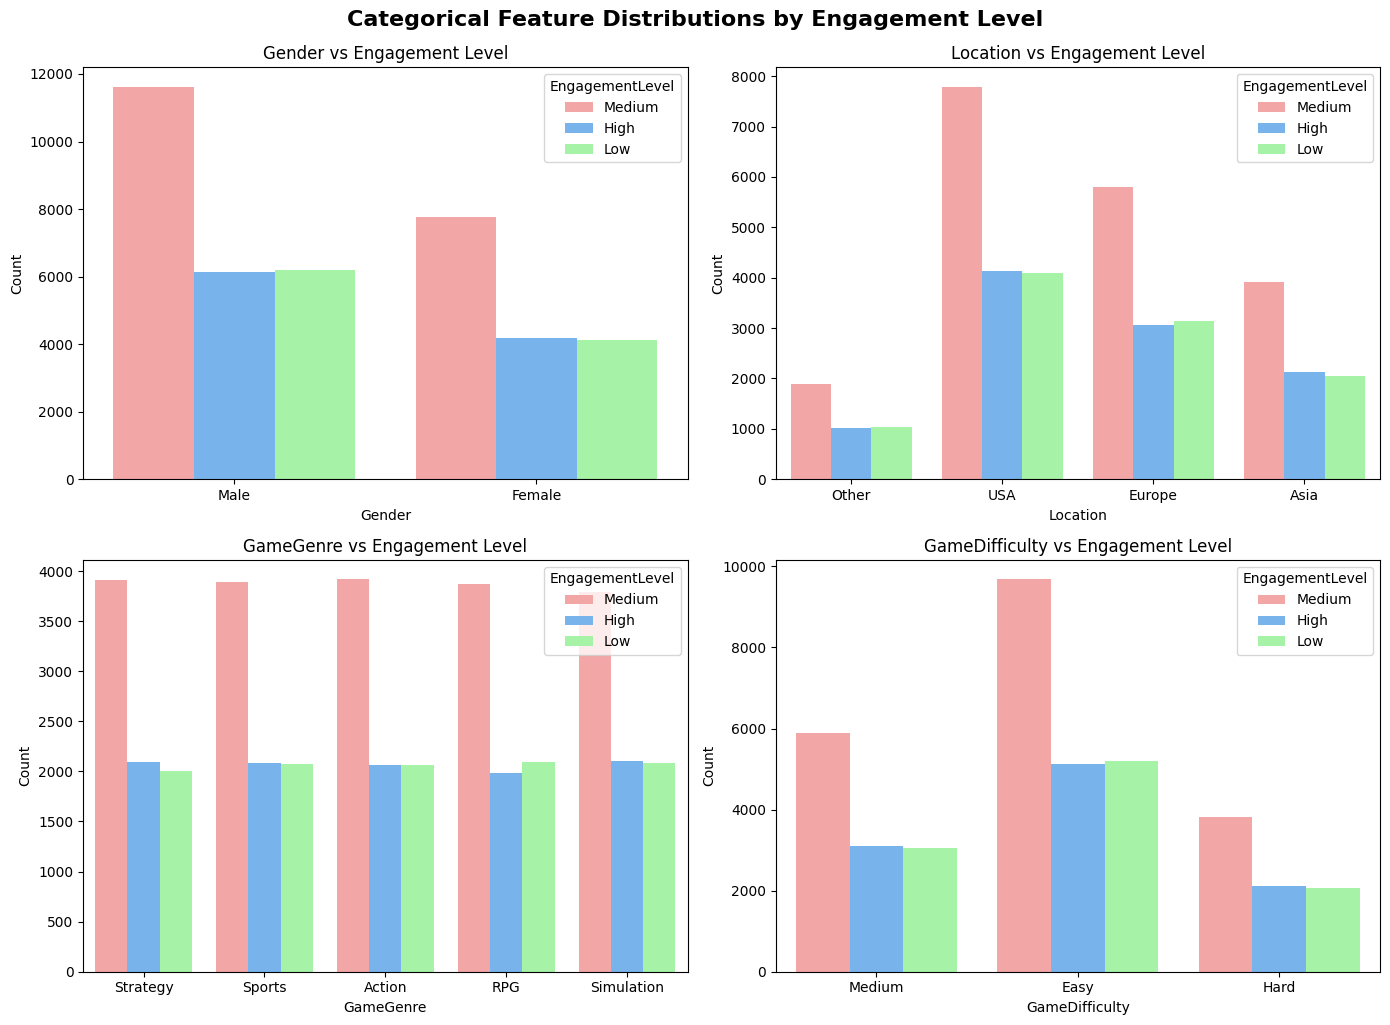

In [5]:
# categorical columns
cat_cols = ['Gender', 'Location', 'GameGenre', 'GameDifficulty']

# Creating charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Plot each categorical column
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='EngagementLevel', 
                  palette=my_colors, ax=axes[i])
    axes[i].set_title(f'{col} vs Engagement Level')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.suptitle('Categorical Feature Distributions by Engagement Level', fontsize=16, fontweight='bold', y=1.02)
plt.show()

## 6.Outlier detection using Boxplots

C:\Users\thuru\AppData\Local\Temp\ipykernel_10216\1832334371.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='EngagementLevel', y=col,
C:\Users\thuru\AppData\Local\Temp\ipykernel_10216\1832334371.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='EngagementLevel', y=col,
C:\Users\thuru\AppData\Local\Temp\ipykernel_10216\1832334371.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='EngagementLevel', y=col,
C:\Users\thuru\AppData\Local\Temp\ipykernel_10216\1832334371.py:7: FutureWarning: 

Passing `pale

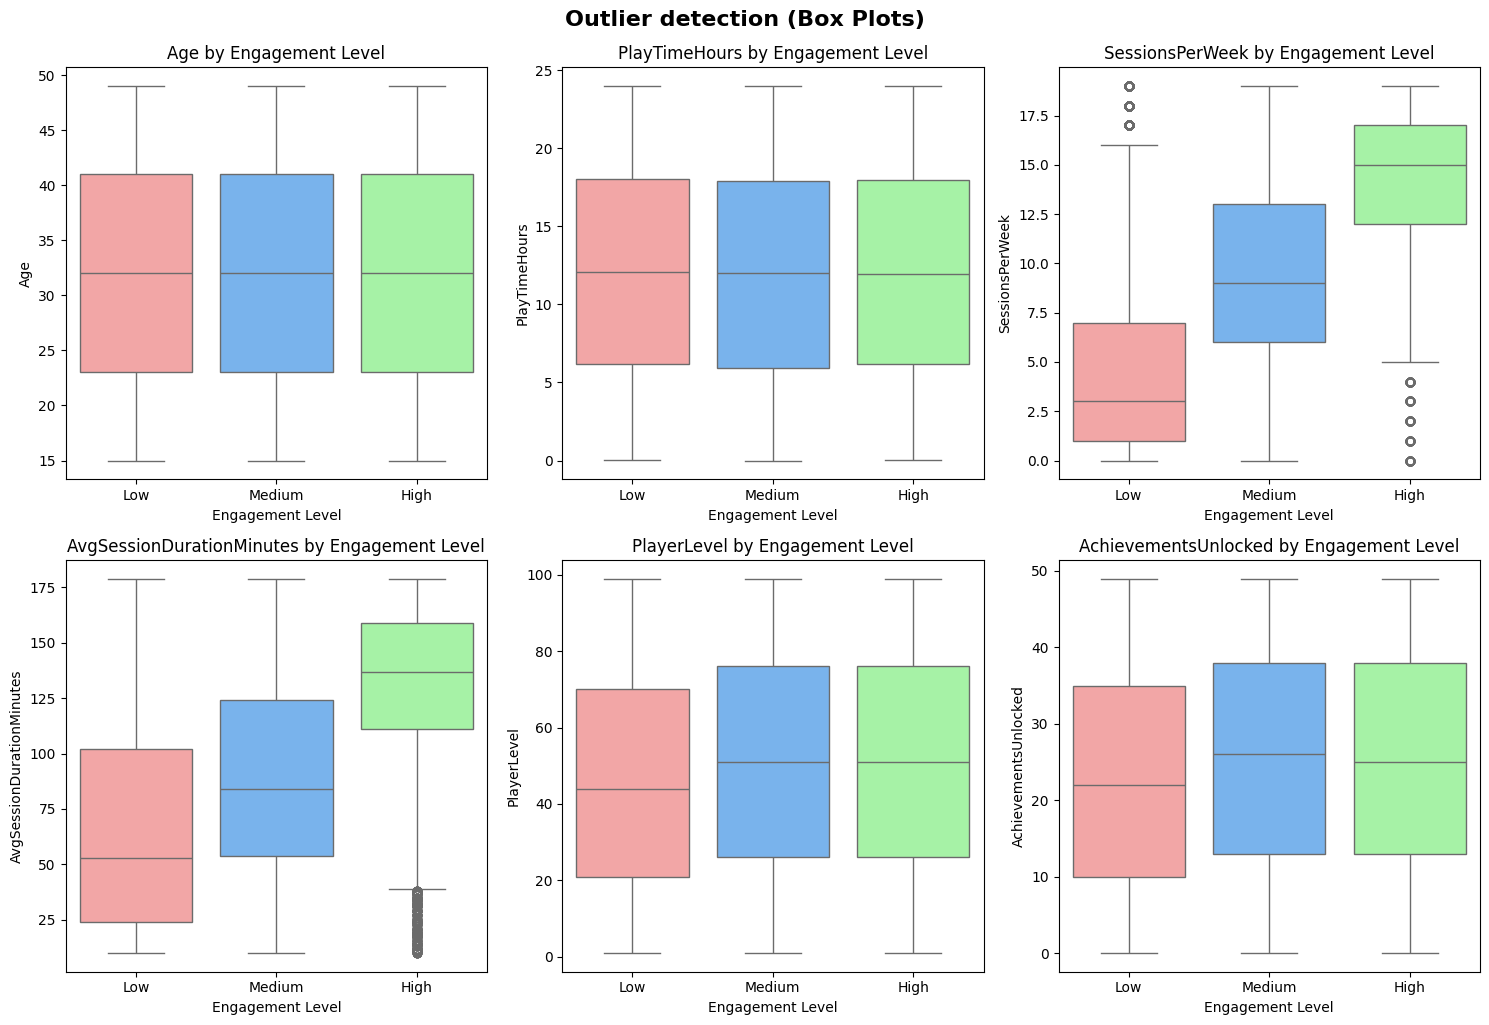

In [6]:
# Box plots for detect outliers in numerical columns by engagement level
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Plot boxplot for each numerical column (ordered Low → Medium → High)
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='EngagementLevel', y=col,
                order=['Low', 'Medium', 'High'],
                palette=my_colors, ax=axes[i])
    axes[i].set_title(f'{col} by Engagement Level')
    axes[i].set_xlabel('Engagement Level')

plt.tight_layout()
plt.suptitle('Outlier detection (Box Plots)', fontsize=16, fontweight='bold', y=1.02)
plt.show()

## 7.Colleration Heatmap

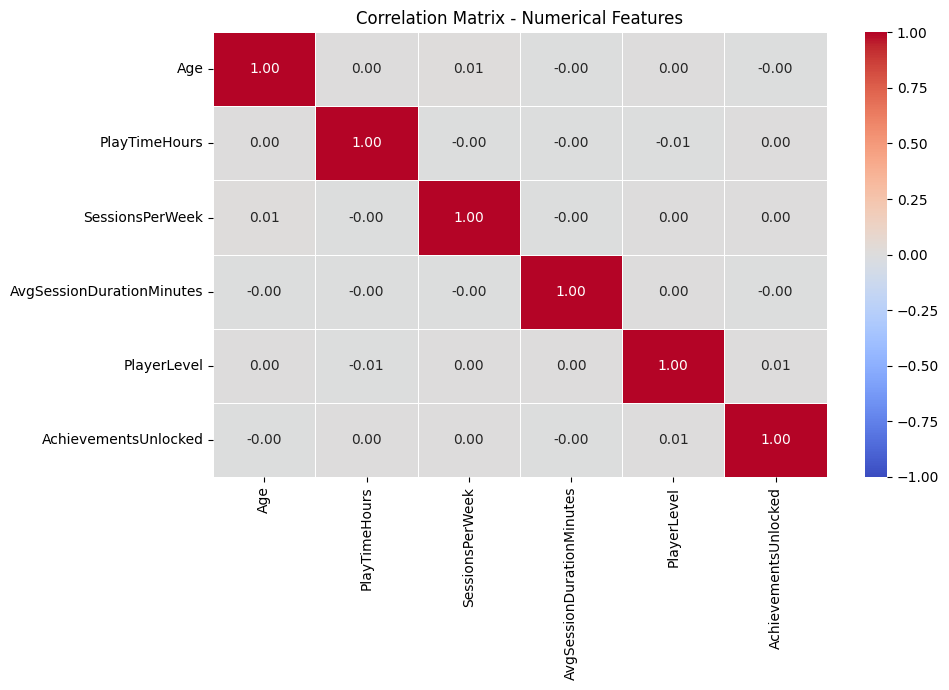

In [14]:
# Calculate correlation between numerical features
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

## 8. Data Preprocessing

In [7]:
# Copy the original dataset so we don't change the original
df_model = df.copy()

# Remove PlayerID - it is just an ID number, not useful for prediction
df_model.drop(columns=['PlayerID'], inplace=True)

# Convert text columns to numbers using LabelEncoder (machine learning needs numbers)
le = LabelEncoder()

# Encode categorical columns
cat_cols = ['Gender', 'Location', 'GameGenre', 'GameDifficulty']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Encode target column (EngagementLevel)
df_model['EngagementLevel'] = le.fit_transform(df_model['EngagementLevel'])

# Check the result
print('Preprocessed Dataset shape:', df_model.shape)
df_model.head()

Preprocessed Dataset shape: (40034, 12)


,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,43,1,2,4,16.271119,0,2,6,108,79,25,2
1,29,0,3,4,5.525961,0,2,5,144,11,10,2
2,22,0,3,3,8.223755,0,0,16,142,35,41,0
3,35,1,3,0,5.265351,1,0,9,85,57,47,2
4,33,1,1,0,15.531945,0,2,2,131,95,37,2


## 9. Define features inputs(X) and target(Y)

In [8]:
# X = input features (everything except EngagementLevel)
X = df_model.drop(columns=['EngagementLevel'])

# y = target column (what we want to predict)
y = df_model['EngagementLevel']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training size:', X_train.shape[0])
print('Testing size :', X_test.shape[0])

# Scale the features (required for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Training size: 32027
Testing size : 8007


# Model Building

## Random Forest Classifier

In [9]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print('Model trained successfully!')

# Predict on test data
rf_pred = rf_model.predict(X_test)
print('Prediction completed!')

# Check accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print('Accuracy :', round(rf_accuracy * 100, 2), '%')
print('F1-Score :', round(rf_f1, 4))

# Detailed results
print(classification_report(y_test, rf_pred)) 

Model trained successfully!
Prediction completed!
Accuracy : 91.0 %
F1-Score : 0.9096
              precision    recall  f1-score   support

           0       0.92      0.87      0.90      2035
           1       0.91      0.88      0.89      2093
           2       0.91      0.95      0.93      3879

    accuracy                           0.91      8007
   macro avg       0.91      0.90      0.91      8007
weighted avg       0.91      0.91      0.91      8007



## KNN Classifier

In [10]:
# Train KNN model (uses scaled features)
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)
print('Model training done!')

# Predict on test data
knn_pred = knn_model.predict(X_test_scaled)
print('Predictions done!')

# Check accuracy
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred, average='weighted')

print('Accuracy :', round(knn_accuracy * 100, 2), '%')
print('F1-Score :', round(knn_f1, 4))

# Detailed results per class
print(classification_report(y_test, knn_pred))

Model training done!
Predictions done!
Accuracy : 77.08 %
F1-Score : 0.7684
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2035
           1       0.78      0.63      0.69      2093
           2       0.75      0.85      0.79      3879

    accuracy                           0.77      8007
   macro avg       0.78      0.75      0.76      8007
weighted avg       0.77      0.77      0.77      8007



## Model Evaluation & Visualizations 
### Confusion matrice

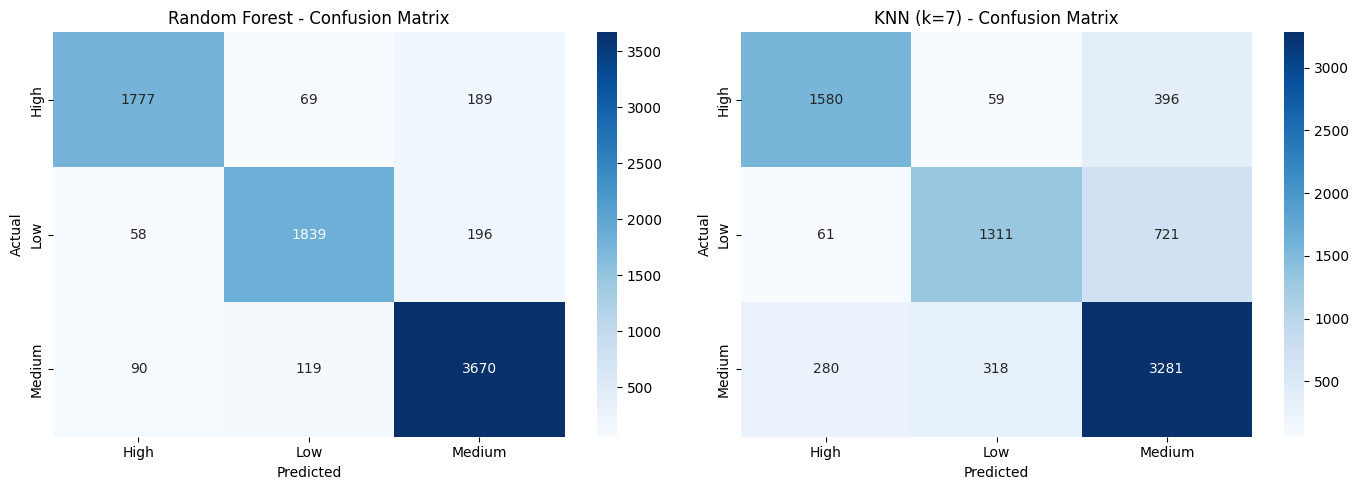

In [11]:
# Class labels
labels = ['High', 'Low', 'Medium']

# Create side by side layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left - Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Random Forest - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Right - KNN confusion matrix
cm_knn = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('KNN (k=7) - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Feature Importance (Random Forest)

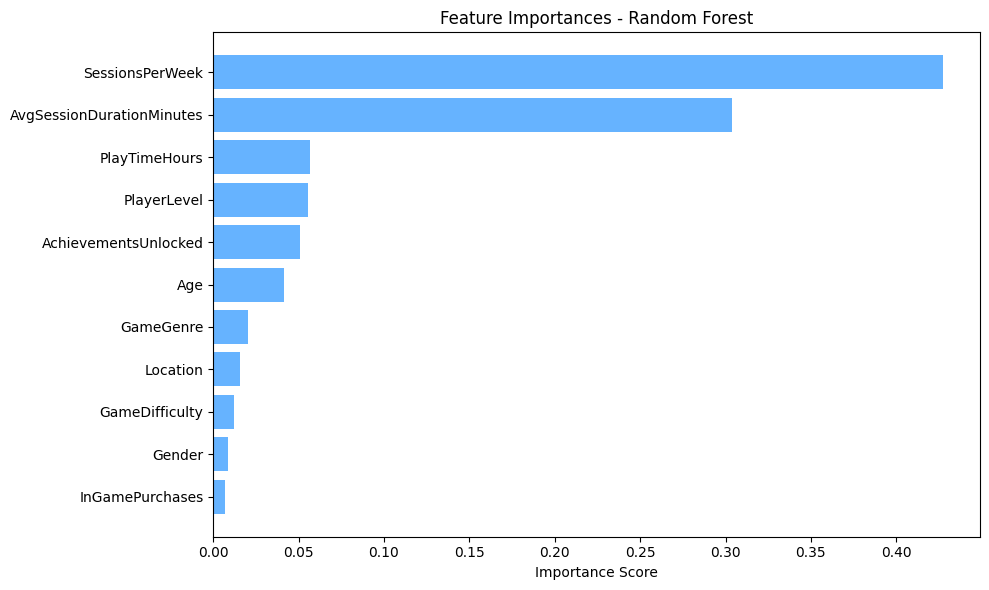

Top 5 most important features:
                      Feature  Importance
7             SessionsPerWeek    0.427640
8   AvgSessionDurationMinutes    0.304045
4               PlayTimeHours    0.056802
9                 PlayerLevel    0.055513
10       AchievementsUnlocked    0.050700


In [12]:
# Getting importance scores from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Put into a dataframe and sort
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='#66b3ff')
plt.xlabel('Importance Score')
plt.title('Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

# most important features
print('Top 5 most important features:')
print(feat_df.sort_values('Importance', ascending=False).head())

## Summary

In [13]:
# Final Results Summary
print('  FINAL RESULTS  ')
print('Random Forest -> Accuracy:', round(rf_accuracy * 100, 2), '% | F1:', round(rf_f1, 4))
print('KNN -> Accuracy:', round(knn_accuracy * 100, 2), '% | F1:', round(knn_f1, 4))


# Best model
print('\nBest Model: Random Forest')

# Key findings
print('\nKey Findings:')
print('- Random Forest performs better than KNN')
print('- Sessions per week and playtime hours are most important features')
print('- No missing values or duplicates in dataset')
print('- Medium engagement class has most players')

# Real world meaning
print('\nReal World Meaning:')
print('- Game developers can predict player engagement')
print('- Helps reduce player dropout and improve retention')

  FINAL RESULTS  
Random Forest -> Accuracy: 91.0 % | F1: 0.9096
KNN -> Accuracy: 77.08 % | F1: 0.7684

Best Model: Random Forest

Key Findings:
- Random Forest performs better than KNN
- Sessions per week and playtime hours are most important features
- No missing values or duplicates in dataset
- Medium engagement class has most players

Real World Meaning:
- Game developers can predict player engagement
- Helps reduce player dropout and improve retention
